# Partial Differential Equations (PDE)
## 2D Heat Equation — Explicit Finite Difference Method

A **Partial Differential Equation** contains partial derivatives with respect to
two or more independent variables — typically space and time.

The **2D heat equation** governs how temperature diffuses in a flat plate:

$$
\frac{\partial T}{\partial t}
= \alpha \!\left( \frac{\partial^2 T}{\partial x^2}
                + \frac{\partial^2 T}{\partial y^2} \right),
\qquad \alpha = \frac{k}{\rho\,c_p} \quad [\text{m}^2/\text{s}]
$$

To solve this numerically we replace every derivative with a finite-difference
approximation on a regular grid. The **explicit (forward Euler)** scheme
computes each new grid point directly from known values at the current step.

| | Explicit FDM | Implicit FDM | Crank–Nicolson |
|--|--|--|--|
| Time stepping | Forward Euler | Backward Euler | Centred average |
| Cost per step | $O(N^2)$ (direct) | $O(N^2)$ (solve LES) | $O(N^2)$ (solve LES) |
| Stability | Conditional: $\gamma \le \tfrac{1}{4}$ | Unconditional | Unconditional |
| Accuracy | $O(\Delta t,\,\Delta x^2)$ | $O(\Delta t,\,\Delta x^2)$ | $O(\Delta t^2,\,\Delta x^2)$ |

---


## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

COLORS = ["#94a3b8", "#64748b", "#7c3aed", "#2563eb", "#ea580c"]


## 2 — Discretising the Heat Equation

### 2.1 The Computational Grid

Divide the square domain $[0, L] \times [0, L]$ into an $N \times N$ grid of
equally-spaced nodes:

$$
x_i = i\,\Delta x, \quad
y_j = j\,\Delta y, \quad
t_k = k\,\Delta t, \qquad
\Delta x = \Delta y = \frac{L}{N-1}
$$

The discrete temperature at node $(i,j)$ and time level $k$ is denoted $T_{i,j}^k$.

### 2.2 Finite-Difference Approximations

Each derivative is replaced by a Taylor-series approximation:

| Derivative | Approximation | Order |
|---|---|:---:|
| $\partial T/\partial t$ (time, forward) | $\dfrac{T_{i,j}^{k+1} - T_{i,j}^k}{\Delta t}$ | $O(\Delta t)$ |
| $\partial^2 T/\partial x^2$ (space, central) | $\dfrac{T_{i+1,j}^k - 2T_{i,j}^k + T_{i-1,j}^k}{(\Delta x)^2}$ | $O(\Delta x^2)$ |
| $\partial^2 T/\partial y^2$ (space, central) | $\dfrac{T_{i,j+1}^k - 2T_{i,j}^k + T_{i,j-1}^k}{(\Delta y)^2}$ | $O(\Delta y^2)$ |

### 2.3 The Explicit Update Rule

Substituting into the heat equation and solving for $T_{i,j}^{k+1}$
(using $\Delta x = \Delta y$):

$$
\boxed{
T_{i,j}^{k+1} = T_{i,j}^k
  + \gamma\!\left(T_{i+1,j}^k + T_{i-1,j}^k + T_{i,j+1}^k + T_{i,j-1}^k
  - 4\,T_{i,j}^k\right)
}
$$

The **local Fourier number** $\gamma$ is the single non-dimensional parameter that
controls the scheme:

$$
\gamma = \frac{\alpha\,\Delta t}{(\Delta x)^2}
$$

It measures how far heat diffuses in one time step relative to the grid spacing.


## 3 — Stability: the $\gamma \le \tfrac{1}{4}$ Condition

A forward-Euler scheme is only **conditionally stable**. If $\gamma$ exceeds a
threshold, round-off errors amplify from step to step and the solution diverges.

Substituting a Fourier mode $T_{i,j}^k = g^k e^{I(p_x i + p_y j)}$ into the
update rule and requiring $|g| \le 1$ for all wavenumbers gives:

$$
\gamma \le \frac{1}{4} \qquad \text{(2-D problem, } \Delta x = \Delta y \text{)}
$$

Re-arranging gives the **maximum allowable time step**:

$$
\Delta t \;\le\; \frac{(\Delta x)^2}{4\,\alpha}
$$

This has an important practical consequence: halving the grid spacing $\Delta x$
requires **four times smaller** $\Delta t$ and therefore **eight times** more
computational work.  That is why implicit (unconditionally stable) methods become
attractive for fine 2-D/3-D grids.


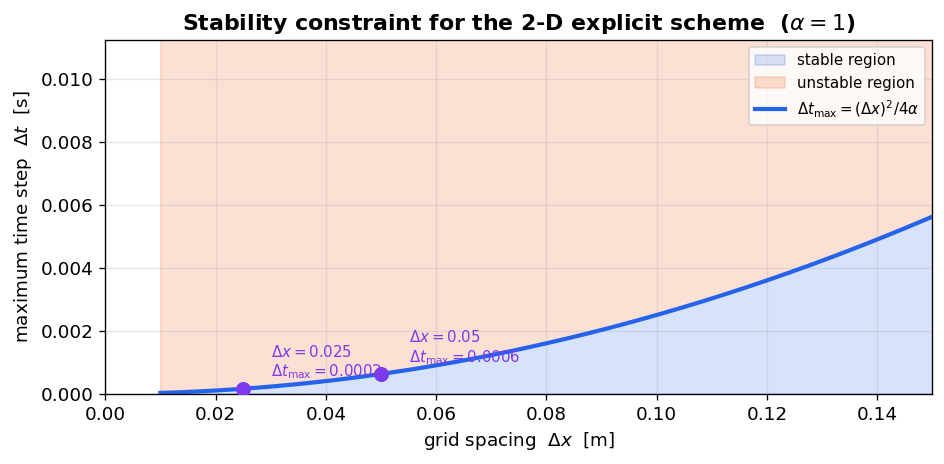

Example constraint table (alpha = 1):
        dx      dt_max   steps for t=0.5
  ----------------------------------------
    0.1000    0.002500               199
    0.0500    0.000625               799
    0.0250    0.000156              3199
    0.0125    0.000039             12799


In [2]:
# Visualise the stability constraint: maximum Dt vs grid spacing
alpha_ref = 1.0                         # normalised diffusivity
dx_vals   = np.linspace(0.01, 0.15, 200)
dt_stable = dx_vals**2 / (4 * alpha_ref)  # stability limit

fig, ax = plt.subplots(figsize=(8, 4))

ax.fill_between(dx_vals, 0, dt_stable,
                color=COLORS[3], alpha=0.18, label="stable region")
ax.fill_between(dx_vals, dt_stable, dt_stable[-1] * 2,
                color=COLORS[4], alpha=0.18, label="unstable region")
ax.plot(dx_vals, dt_stable, color=COLORS[3], lw=2.5,
        label=r"$\Delta t_{\max} = (\Delta x)^2 / 4\alpha$")

# Mark two example grid spacings
for dx_ex, label_ex in [(0.05, r"$\Delta x = 0.05$"), (0.025, r"$\Delta x = 0.025$")]:
    dt_ex = dx_ex**2 / (4 * alpha_ref)
    ax.plot(dx_ex, dt_ex, "o", color=COLORS[2], markersize=8, zorder=5)
    ax.annotate(f"{label_ex}\n$\\Delta t_{{\\max}}={dt_ex:.4f}$",
                xy=(dx_ex, dt_ex), xytext=(dx_ex + 0.005, dt_ex + dt_stable[-1]*0.07),
                fontsize=9, color=COLORS[2])

ax.set_xlabel(r"grid spacing  $\Delta x$  [m]")
ax.set_ylabel(r"maximum time step  $\Delta t$  [s]")
ax.set_title(r"Stability constraint for the 2-D explicit scheme  ($\alpha = 1$)",
             fontweight="bold")
ax.set_xlim(0, 0.15)
ax.set_ylim(0, dt_stable[-1] * 2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print("Example constraint table (alpha = 1):")
print(f"  {'dx':>8}  {'dt_max':>10}  {'steps for t=0.5':>16}")
print("  " + "-" * 40)
for dx in [0.1, 0.05, 0.025, 0.0125]:
    dt_max = dx**2 / (4 * alpha_ref)
    n = int(0.5 / dt_max)
    print(f"  {dx:>8.4f}  {dt_max:>10.6f}  {n:>16d}")


## 4 — Problem Definition

We solve the heat equation on the unit square with the following
boundary and initial conditions:

$$
\Omega = [0,1]\times[0,1], \qquad
\alpha = 1\text{ (normalised)}
$$

**Boundary conditions (Dirichlet):**

$$
T(x, 1, t) = 100 \quad \text{(hot top wall)}, \qquad
T = 0 \quad \text{on the other three walls}
$$

**Initial condition:**

$$
T(x, y, 0) = 0 \quad \text{for all interior points}
$$

The exact **steady-state** solution (Laplace equation $\nabla^2 T = 0$) is
obtained by separation of variables:

$$
T_{\infty}(x,y)
= \frac{4 T_{\text{hot}}}{\pi}
  \sum_{\substack{n=1,3,5,\ldots}}^{\infty}
  \frac{\sin(n\pi x/L)\,\sinh(n\pi y/L)}{n\,\sinh(n\pi)}
$$

We will use this analytical result to validate the numerical solution.


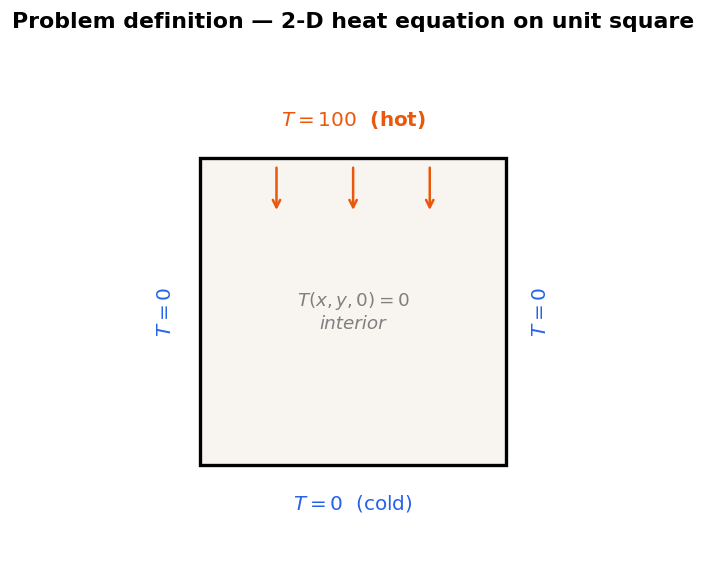

In [3]:
# Draw the domain with annotated boundary conditions

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect("equal")
ax.set_xlim(-0.35, 1.35)
ax.set_ylim(-0.35, 1.35)
ax.axis("off")

# Domain square
rect = mpatches.FancyBboxPatch((0, 0), 1, 1, linewidth=2,
                                edgecolor="black", facecolor="#f8f4f0",
                                boxstyle="square,pad=0")
ax.add_patch(rect)

# Boundary labels
ax.text(0.5, 1.09, r"$T = 100$  (hot)", ha="center", va="bottom",
        fontsize=12, color=COLORS[4], fontweight="bold")
ax.text(0.5, -0.09, r"$T = 0$  (cold)", ha="center", va="top",
        fontsize=12, color=COLORS[3])
ax.text(-0.08, 0.5, r"$T = 0$", ha="right", va="center",
        fontsize=12, color=COLORS[3], rotation=90)
ax.text(1.08, 0.5, r"$T = 0$", ha="left", va="center",
        fontsize=12, color=COLORS[3], rotation=90)

# Interior label
ax.text(0.5, 0.5, r"$T(x,y,0) = 0$" + "\n" + r"interior",
        ha="center", va="center", fontsize=11, color="grey",
        style="italic")

# Arrows indicating heat flow direction
for xp in [0.25, 0.5, 0.75]:
    ax.annotate("", xy=(xp, 0.82), xytext=(xp, 0.98),
                arrowprops=dict(arrowstyle="->", color=COLORS[4], lw=1.5))

ax.set_title("Problem definition — 2-D heat equation on unit square",
             fontweight="bold", pad=14)
fig.tight_layout()
plt.show()


## 5 — Explicit FD Solver

In [4]:
def solve_heat_2d(nx, alpha, L, T_hot, t_end, gamma_frac=0.24):
    "Explicit FD solver for the 2-D heat equation on a square domain."
    dx    = L / (nx - 1)
    gamma = gamma_frac * 0.25        # Fourier number (fraction of limit)
    dt    = gamma * dx**2 / alpha
    n_steps = int(np.ceil(t_end / dt))

    x = np.linspace(0, L, nx)
    y = np.linspace(0, L, nx)

    # Initialise — row index i increases with y (row 0 = y=0, row -1 = y=L)
    T = np.zeros((nx, nx), dtype=float)
    T[-1, :] = T_hot     # hot top wall   (y = L)
    # other three walls remain at 0

    # Decide when to save snapshots: approximately 8 equally-spaced frames
    save_every = max(1, n_steps // 8)
    times  = [0.0]
    fields = [T.copy()]

    for k in range(n_steps):
        T_new = T.copy()
        T_new[1:-1, 1:-1] = ((1 - 4*gamma) * T[1:-1, 1:-1]
                             + gamma * (T[2:,  1:-1] + T[:-2, 1:-1]
                                      + T[1:-1, 2:] + T[1:-1, :-2]))
        # Re-enforce Dirichlet BCs
        T_new[-1, :] = T_hot
        T_new[0, :]  = 0
        T_new[:, 0]  = 0
        T_new[:, -1] = 0
        T = T_new

        if (k + 1) % save_every == 0:
            times.append((k + 1) * dt)
            fields.append(T.copy())

    # Guarantee the final step is recorded
    if abs(times[-1] - n_steps * dt) > 1e-12:
        times.append(n_steps * dt)
        fields.append(T.copy())

    return times, fields, x, y, dt, gamma


def steady_state_analytical(x, y, T_hot, L, n_terms=40):
    "Analytical steady-state via separation of variables (stable for large n)."
    # The ratio sinh(n*pi*y/L) / sinh(n*pi) overflows for large n.
    # Use the identity exp(a-b)*(1-exp(-2a))/(1-exp(-2b)) for a=n*pi*y, b=n*pi.
    XX, YY = np.meshgrid(x, y)      # YY[i,j] = y_i,  XX[i,j] = x_j
    T_ss = np.zeros_like(XX)
    for n in range(1, 2 * n_terms, 2):   # odd terms only
        npi = n * np.pi / L
        a = npi * YY                # n*pi*y/L
        b = npi * L                 # n*pi

        # Stable ratio sinh(npi*y) / sinh(npi)
        # For b > 50, sinh(a)/sinh(b) = exp(a-b)*(1-exp(-2a))/(1-exp(-2b))
        if b > 50:
            ratio = np.exp(a - b) * np.where(
                a > 1e-6,
                (1 - np.exp(-2 * a)) / (1 - np.exp(-2 * b)),
                2 * a / (1 - np.exp(-2 * b)))  # L'Hopital near a=0
        else:
            ratio = np.sinh(a) / np.sinh(b)

        T_ss += (4 * T_hot / (n * np.pi)) * np.sin(npi * XX) * ratio
    return T_ss


# --- Shared parameters for all sections ---------------------------------
ALPHA  = 1.0      # normalised thermal diffusivity
L      = 1.0      # domain side length
T_HOT  = 100.0    # hot-wall temperature
T_END  = 0.5      # total simulation time  (Fourier number alpha*t/L^2 = 0.5)
NX     = 31       # grid size (31 x 31)

print(f"Grid:    {NX} x {NX}  (dx = {L/(NX-1):.4f})")

times, fields, x, y, dt, gamma = solve_heat_2d(NX, ALPHA, L, T_HOT, T_END)

print(f"dt:      {dt:.6f}  (gamma = {gamma:.4f})")
print(f"Steps:   {len(times)-1}  snapshots saved: {len(times)}")
print(f"t_final: {times[-1]:.4f}")


Grid:    31 x 31  (dx = 0.0333)
dt:      0.000067  (gamma = 0.0600)
Steps:   9  snapshots saved: 10
t_final: 0.5000


## 6 — Temperature Field Evolution

The eight panels below show how the temperature field develops from the initial
cold slab ($T=0$ everywhere) toward the steady-state distribution. The hot top
wall drives a diffusion wavefront downward; the cold side walls create the
characteristic arched isolines at steady state.


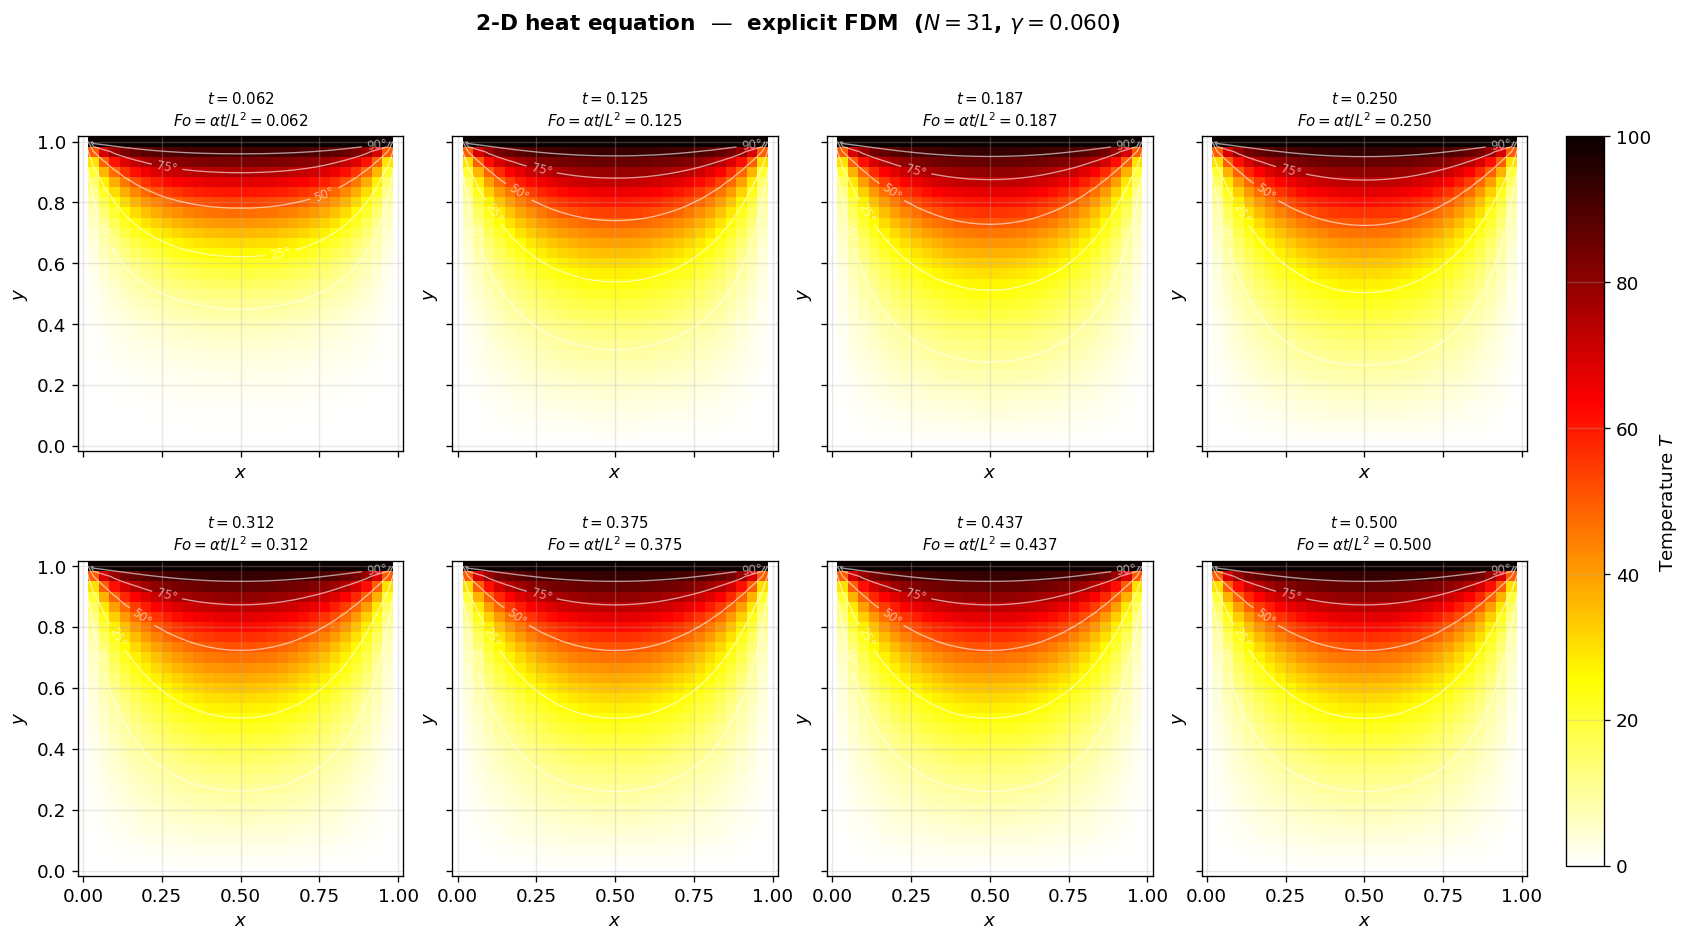

In [5]:
XX, YY = np.meshgrid(x, y)   # shape (nx, nx)

# Use only 8 non-zero snapshots
snaps_to_plot = [(t, f) for t, f in zip(times[1:], fields[1:])][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, (t, T_snap) in zip(axes.flat, snaps_to_plot):
    pcm = ax.pcolormesh(XX, YY, T_snap, cmap="hot_r",
                        vmin=0, vmax=T_HOT, shading="auto")
    cs  = ax.contour(XX, YY, T_snap,
                     levels=[10, 25, 50, 75, 90], colors="white",
                     linewidths=0.8, alpha=0.6)
    ax.clabel(cs, fmt="%g°", fontsize=7, inline=True)
    fo = ALPHA * t / L**2
    ax.set_title(f"$t = {t:.3f}$\n$Fo = \\alpha t/L^2 = {fo:.3f}$",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

# Shared colourbar
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.15)
cbar_ax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
fig.colorbar(pcm, cax=cbar_ax, label="Temperature $T$")

fig.suptitle(f"2-D heat equation  —  explicit FDM  "
             f"($N={NX}$, $\\gamma={gamma:.3f}$)",
             fontsize=13, fontweight="bold", y=1.01)
plt.show()


## 7 — Vertical Cross-Section Along the Centreline

Plotting $T(x=L/2,\,y,\,t)$ at successive times shows how the diffusion
wavefront propagates downward from the hot wall. The dashed black curve is the
**analytical steady-state** — the limiting profile the numerical solution
approaches as $t \to \infty$.


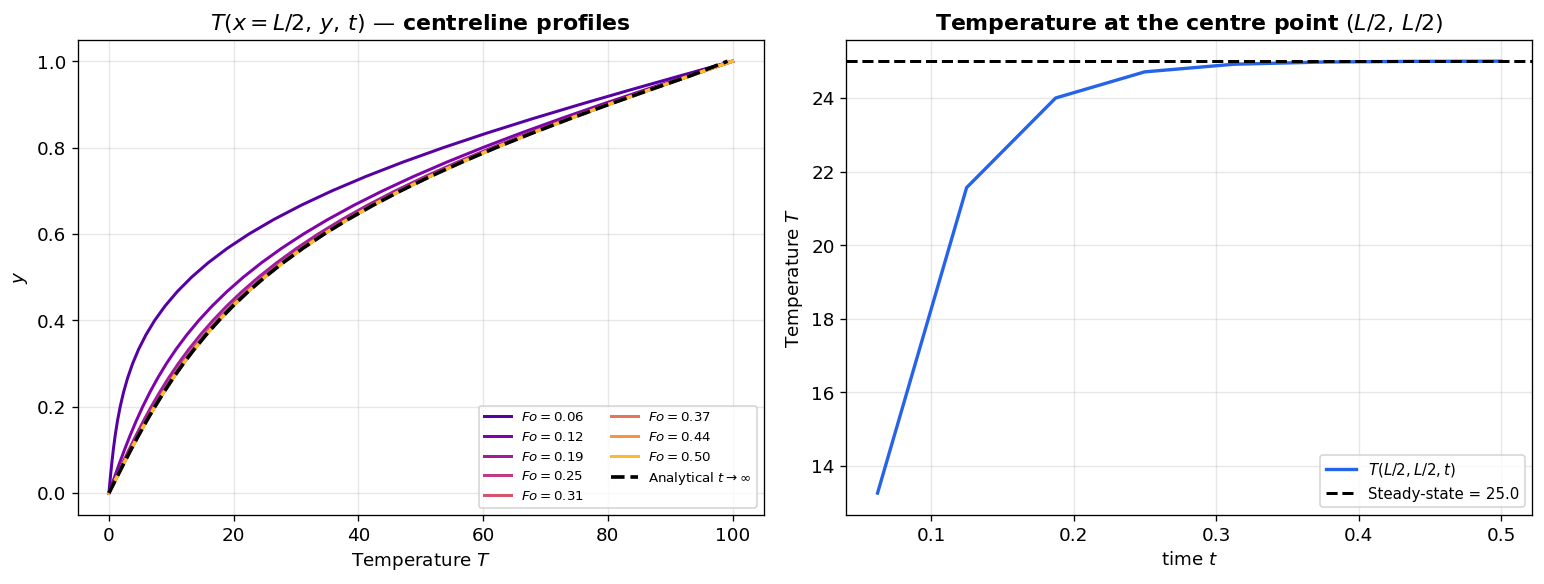

Centre temperature at t_final = 25.00
Analytical steady-state value = 25.00
Remaining error               = 0.00  (Fo = 0.50, not yet fully converged)


In [6]:
# Analytical steady-state on the full grid
T_ss = steady_state_analytical(x, y, T_HOT, L)

# Centreline index (x = L/2)
mid = NX // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: T vs y along centreline at successive snapshots ---
ax = axes[0]
cmap_line = plt.cm.plasma
n_lines = len(snaps_to_plot)
for k, (t, T_snap) in enumerate(snaps_to_plot):
    c = cmap_line(0.15 + 0.7 * k / (n_lines - 1))
    fo = ALPHA * t / L**2
    ax.plot(T_snap[:, mid], y, color=c, lw=1.8,
            label=f"$Fo={fo:.2f}$")
ax.plot(T_ss[:, mid], y, "k--", lw=2.2, label="Analytical $t\\to\\infty$")
ax.set_xlabel("Temperature $T$")
ax.set_ylabel("$y$")
ax.set_title(r"$T(x=L/2,\,y,\,t)$ — centreline profiles",
             fontweight="bold")
ax.legend(fontsize=8, ncol=2, loc="lower right")

# --- Right: T vs time at the centre point (L/2, L/2) ---
ax = axes[1]
t_arr = np.array([t for t, _ in zip(times[1:], fields[1:])])
T_centre = np.array([f[NX // 2, mid] for f in fields[1:]])
T_ss_centre = T_ss[NX // 2, mid]

ax.plot(t_arr, T_centre, color=COLORS[3], lw=2, label="$T(L/2, L/2, t)$")
ax.axhline(T_ss_centre, color="k", ls="--", lw=1.8,
           label=f"Steady-state = {T_ss_centre:.1f}")
ax.set_xlabel("time $t$")
ax.set_ylabel("Temperature $T$")
ax.set_title(r"Temperature at the centre point $(L/2,\, L/2)$",
             fontweight="bold")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"Centre temperature at t_final = {T_centre[-1]:.2f}")
print(f"Analytical steady-state value = {T_ss_centre:.2f}")
print(f"Remaining error               = {abs(T_centre[-1] - T_ss_centre):.2f}  "
      f"(Fo = {ALPHA*times[-1]/L**2:.2f}, not yet fully converged)")


## 8 — Stability Violation

What happens when $\gamma > \tfrac{1}{4}$? High-frequency error modes are
**amplified** at each step rather than damped. The amplification factor for
the worst-case Fourier mode is $|g| = |1 - 8\gamma|$; once $|g| > 1$ errors
grow without bound.

| $\gamma$ | $1 - 4\gamma$ | $|g|_{\max}$ | Behaviour |
|:---:|:---:|:---:|---|
| 0.20 | 0.20 | 0.60 | Stable — errors decay |
| 0.25 | 0.00 | 1.00 | Marginal — errors neither grow nor decay |
| 0.30 | −0.20 | 1.40 | **Unstable — errors grow 40% per step** |

The upper row of panels below shows the temperature field at $t = 0.10$;
the lower row tracks the temperature at the centre point over time.


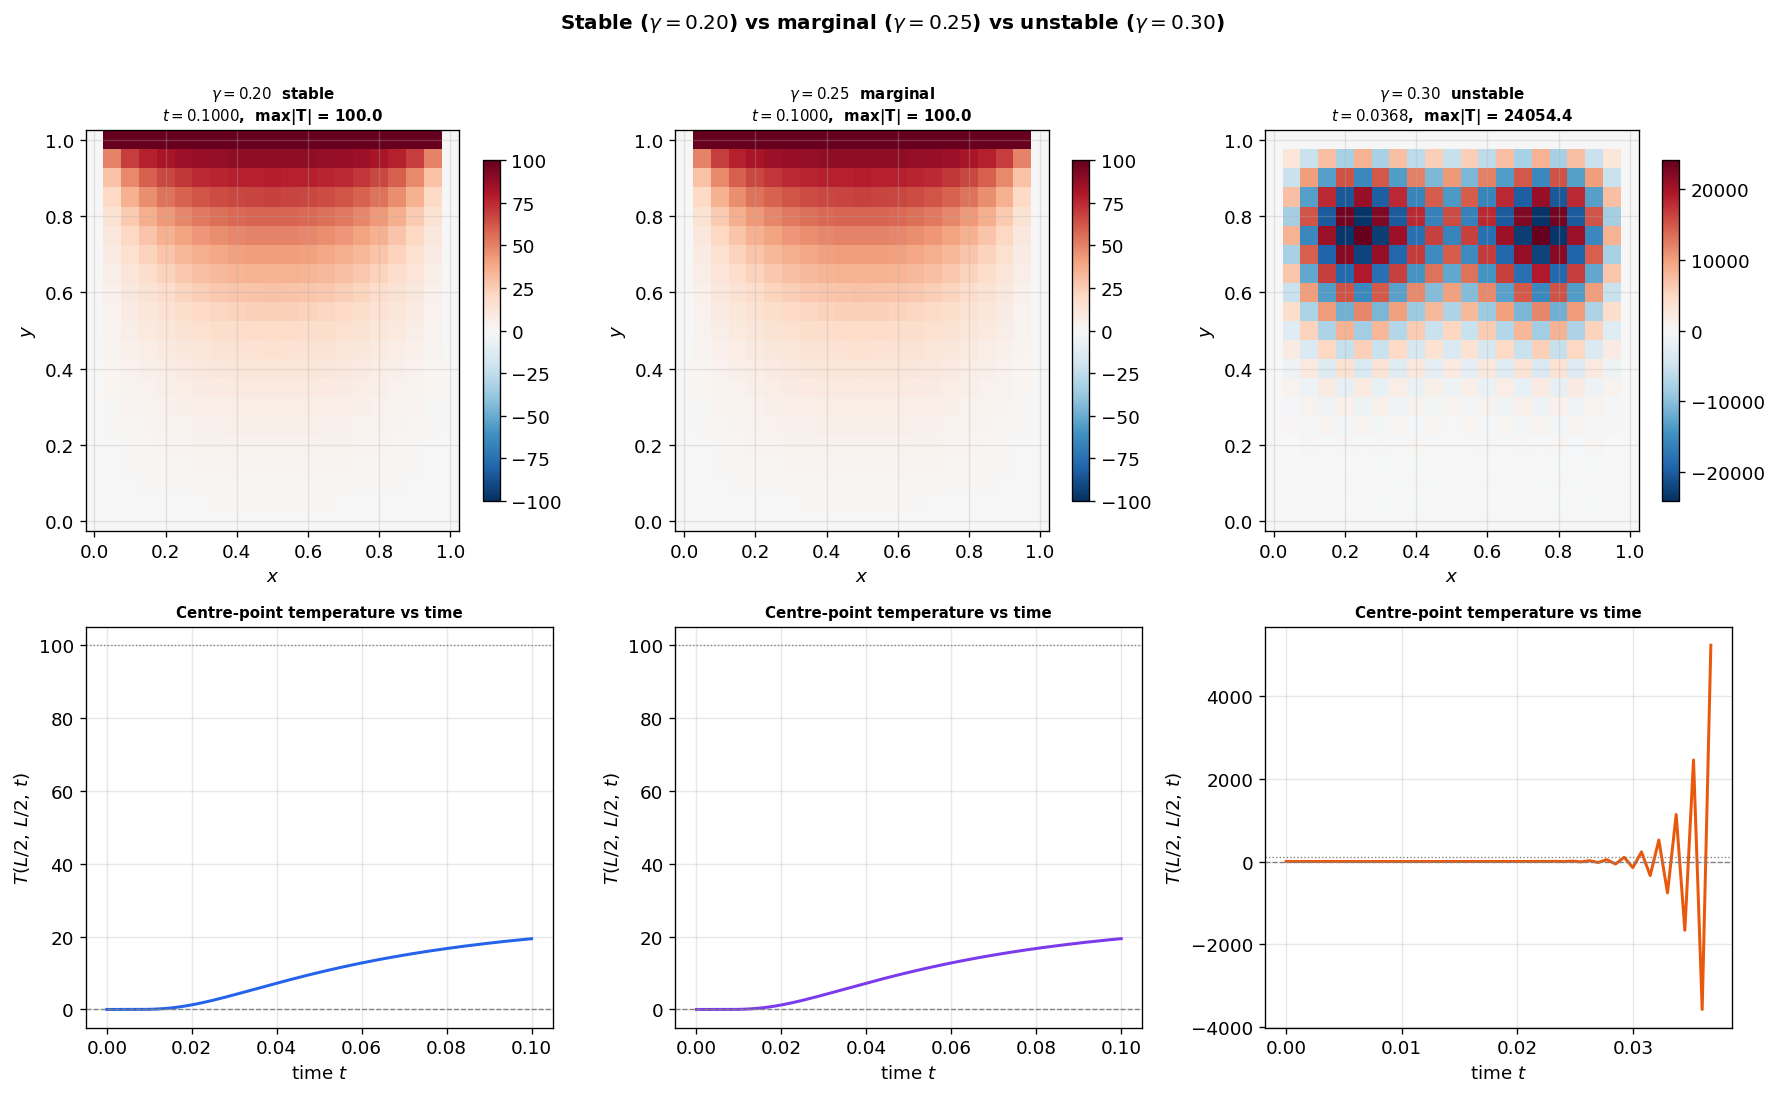

In [7]:
# The instability is revealed by tracking the interior centre-node value,
# which is NOT clamped by the BCs.  We run until either t_max is reached
# or the centre temperature diverges past 10*T_HOT.

gamma_fracs = [0.80, 1.00, 1.20]   # fractions of the 0.25 stability limit
gamma_vals  = [gf * 0.25 for gf in gamma_fracs]
labels_g    = [r"$\gamma = 0.20$  stable",
               r"$\gamma = 0.25$  marginal",
               r"$\gamma = 0.30$  unstable"]
nx_demo     = 21
t_demo      = 0.10

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col_idx, (gf, gv, lbl) in enumerate(zip(gamma_fracs, gamma_vals, labels_g)):
    ax_top = axes[0, col_idx]
    ax_bot = axes[1, col_idx]

    # --- manual time-stepping so we can stop early and record centre ---
    dx    = L / (nx_demo - 1)
    dt    = gv * dx**2 / ALPHA
    n_max = int(np.ceil(t_demo / dt))
    xd = np.linspace(0, L, nx_demo)
    yd = np.linspace(0, L, nx_demo)

    T = np.zeros((nx_demo, nx_demo))
    T[-1, :] = T_HOT
    mid_d = nx_demo // 2

    t_hist = [0.0]
    c_hist = [T[mid_d, mid_d]]

    for k in range(n_max):
        T_new = T.copy()
        T_new[1:-1, 1:-1] = ((1 - 4*gv) * T[1:-1, 1:-1]
                             + gv * (T[2:, 1:-1] + T[:-2, 1:-1]
                                   + T[1:-1, 2:] + T[1:-1, :-2]))
        T_new[-1, :] = T_HOT
        T_new[0, :] = T_new[:, 0] = T_new[:, -1] = 0
        T = T_new
        t_now = (k + 1) * dt
        t_hist.append(t_now)
        c_hist.append(T[mid_d, mid_d])
        if abs(T[mid_d, mid_d]) > 50 * T_HOT:   # stop if truly diverged
            break

    t_hist = np.array(t_hist)
    c_hist = np.array(c_hist)

    # Top row: temperature field at the final recorded step
    XX_d, YY_d = np.meshgrid(xd, yd)
    lim = max(T_HOT, abs(T).max())
    pcm = ax_top.pcolormesh(XX_d, YY_d, T, cmap="RdBu_r",
                             vmin=-lim, vmax=lim, shading="auto")
    fig.colorbar(pcm, ax=ax_top, shrink=0.85)
    ax_top.set_title(f"{lbl}\n$t = {t_hist[-1]:.4f}$,  "
                     f"max|T| = {abs(T).max():.1f}",
                     fontsize=9, fontweight="bold")
    ax_top.set_xlabel("$x$"); ax_top.set_ylabel("$y$")

    # Bottom row: centre-point temperature vs time
    ax_bot.plot(t_hist, c_hist,
                color=[COLORS[3], COLORS[2], COLORS[4]][col_idx], lw=1.8)
    ax_bot.axhline(0,     color="grey", lw=0.8, ls="--")
    ax_bot.axhline(T_HOT, color="grey", lw=0.8, ls=":")
    ax_bot.set_xlabel("time $t$")
    ax_bot.set_ylabel(r"$T(L/2,\,L/2,\,t)$")
    ax_bot.set_title("Centre-point temperature vs time", fontsize=9,
                     fontweight="bold")

fig.suptitle(r"Stable ($\gamma=0.20$) vs marginal ($\gamma=0.25$) "
             r"vs unstable ($\gamma=0.30$)",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 9 — Grid Refinement and Convergence

Refining the grid simultaneously improves accuracy *and* forces a smaller
time step. We compare the numerical interior-point RMS error against the
analytical steady-state solution at four grid resolutions.

For the comparison to be purely about **spatial accuracy**, the simulation
must run long enough that the transient has decayed:
the slowest mode decays as $e^{-\pi^2 \alpha t / L^2}$, which is
$< 10^{-8}$ at $Fo = 2$. Beyond that point only spatial error remains.

> **Corner note.** The boundary condition is *discontinuous* at the top
> corners: $T$ jumps from $0$ (cold wall) to $T_{\text{hot}}$ at $x=0,\,y=L$
> and $x=L,\,y=L$. This corner singularity means higher derivatives of the
> true solution are unbounded there, which limits the *global* RMS convergence
> rate to approximately $O(\Delta x)$ rather than the expected $O(\Delta x^2)$
> of central differences. **Far from the corners** (see the centreline profiles)
> the local accuracy is indeed $O(\Delta x^2)$. This is a common and important
> lesson in practice: second-order accuracy in theory requires a smooth solution.


Running grid refinement study (Fo = 2.0)...
  N= 11, dx=0.1000, steps=     9, RMS=2.3473e-01
  N= 21, dx=0.0500, steps=     9, RMS=1.1155e-01


  N= 41, dx=0.0250, steps=     9, RMS=5.4112e-02


  N= 81, dx=0.0125, steps=     9, RMS=2.7836e-02


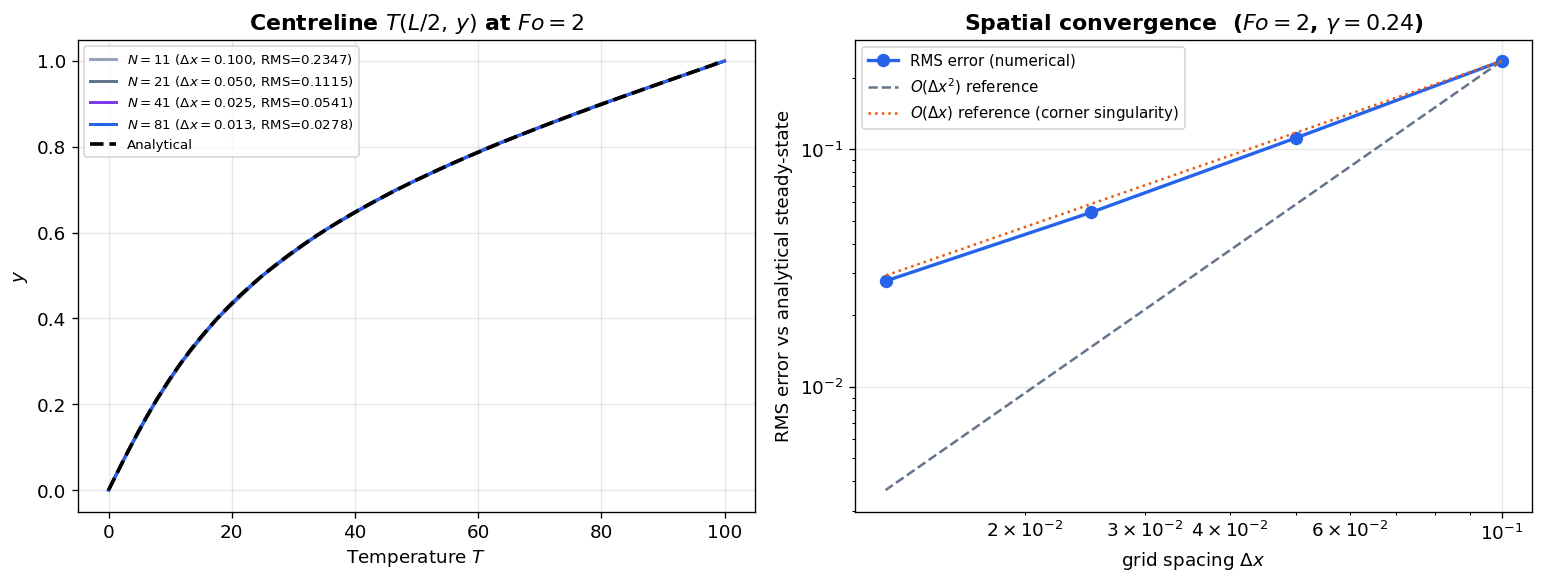


    N        dx          dt     steps     RMS error
  ----------------------------------------------------
   11    0.1000    0.002400       833      0.234733
   21    0.0500    0.000600      3333      0.111547
   41    0.0250    0.000150     13333      0.054112
   81    0.0125    0.000038     53333      0.027836


In [8]:
grid_sizes  = [11, 21, 41, 81]
grid_colors = COLORS
t_compare   = 2.0      # Fourier number 2.0 — transient has fully decayed

print("Running grid refinement study (Fo = 2.0)...")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rms_errors = []
dx_vals_g  = []

for nx_g, col in zip(grid_sizes, grid_colors):
    t_l, f_l, xg, yg, dtg, gg = solve_heat_2d(
        nx_g, ALPHA, L, T_HOT, t_compare, gamma_frac=0.96)

    T_num = f_l[-1]
    T_ana = steady_state_analytical(xg, yg, T_HOT, L)
    # RMS over interior nodes only (boundary values are exact by construction)
    rms   = float(np.sqrt(np.mean((T_num[1:-1, 1:-1] - T_ana[1:-1, 1:-1])**2)))
    rms_errors.append(rms)

    dx_g  = L / (nx_g - 1)
    dx_vals_g.append(dx_g)
    mid_g = nx_g // 2

    # Centreline profile
    axes[0].plot(T_num[:, mid_g], yg, color=col, lw=1.8,
                 label=f"$N={nx_g}$ ($\\Delta x={dx_g:.3f}$, RMS={rms:.4f})")
    print(f"  N={nx_g:3d}, dx={dx_g:.4f}, steps={len(t_l)-1:6d}, "
          f"RMS={rms:.4e}")

# Analytical centreline
x_ref = np.linspace(0, L, 300)
y_ref = np.linspace(0, L, 300)
T_ref = steady_state_analytical(x_ref, y_ref, T_HOT, L)
axes[0].plot(T_ref[:, 150], y_ref, "k--", lw=2.2, label="Analytical")
axes[0].set_xlabel("Temperature $T$")
axes[0].set_ylabel("$y$")
axes[0].set_title(r"Centreline $T(L/2,\,y)$ at $Fo = 2$",
                  fontweight="bold")
axes[0].legend(fontsize=8)

# Convergence plot: RMS error vs dx
axes[1].loglog(dx_vals_g, rms_errors, "o-", color=COLORS[3],
               lw=2, markersize=7, label="RMS error (numerical)")

# Reference slopes: O(h^1) and O(h^2)
h_ref = np.array([dx_vals_g[0], dx_vals_g[-1]])
axes[1].loglog(h_ref, rms_errors[0] * (h_ref / h_ref[0])**2,
               "--", color=COLORS[1], lw=1.5, label=r"$O(\Delta x^2)$ reference")
axes[1].loglog(h_ref, rms_errors[0] * (h_ref / h_ref[0])**1,
               ":",  color=COLORS[4], lw=1.5, label=r"$O(\Delta x)$ reference (corner singularity)")

axes[1].set_xlabel(r"grid spacing $\Delta x$")
axes[1].set_ylabel("RMS error vs analytical steady-state")
axes[1].set_title(r"Spatial convergence  ($Fo = 2$, $\gamma = 0.24$)",
                  fontweight="bold")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"\n{'N':>5}  {'dx':>8}  {'dt':>10}  {'steps':>8}  {'RMS error':>12}")
print("  " + "-" * 52)
for nx_g, rms in zip(grid_sizes, rms_errors):
    dx_g = L / (nx_g - 1)
    dt_g = 0.96 * 0.25 * dx_g**2 / ALPHA
    n_g  = int(t_compare / dt_g)
    print(f"  {nx_g:>3d}  {dx_g:>8.4f}  {dt_g:>10.6f}  {n_g:>8d}  {rms:>12.6f}")


## 10 — Notes for Students

### Key take-aways

1. **Discretise, then algebraise.** Every PDE solver follows the same three-step
   recipe: (i) lay down a grid, (ii) replace each derivative with a
   finite-difference approximation, (iii) rearrange to get a formula for the next
   unknown. The *explicit* scheme is the simplest because the formula is direct —
   no linear system to solve.

2. **The Fourier number $\gamma$ controls everything.**
   It appears in both the update formula and the stability condition.
   A value close to $\tfrac{1}{4}$ gives large time steps (efficient) but leaves no
   margin; a value around $0.20$–$0.24$ is a safe practical choice.

3. **Halving $\Delta x$ costs $64\times$ more work in 2-D.**
   The stability constraint forces $\Delta t \propto (\Delta x)^2$. Halving $\Delta x$
   gives $4\times$ more grid points, $4\times$ more time steps, and the same
   computational cost per point — totalling $4^2 \cdot 4 / 4 = 16$ times more work
   per spatial dimension, or roughly $64\times$ more for a 2-D problem.
   This is why implicit methods, though costlier per step, win at fine resolutions.

4. **$O(\Delta x^2)$ accuracy requires a smooth solution.**
   Central differences give *local* truncation error $O(\Delta x^2)$, but the *global*
   RMS error can be lower order. In Section 9 the global convergence rate was
   observed to be approximately $O(\Delta x)$, not $O(\Delta x^2)$. The reason
   is the **corner singularity**: the boundary condition jumps from $T = 0$ (cold
   side walls) to $T = T_{\text{hot}}$ at the top corners, making higher derivatives
   of the solution unbounded there and limiting the global accuracy. **At interior
   points far from the corners, the local error is still $O(\Delta x^2)$** — exactly
   as the centreline profiles in Section 9 show. This is a common practical warning:
   second-order accuracy is achieved only where the solution is smooth enough.

5. **The steady-state is a Laplace problem** ($\nabla^2 T = 0$), with an
   analytical solution via separation of variables (Section 4). Comparing against
   it is the standard *verification* step: it confirms the code is solving the
   correct equations correctly.

6. **Stability ≠ accuracy.** The $\gamma = 0.25$ case is *barely* stable — the
   central node's self-contribution drops to zero, which can produce checkerboard
   artefacts on adversarial initial data. The $\gamma = 0.30$ case diverges within
   a few hundred steps, as the instability amplification factor $|1 - 8\gamma| = 1.4$
   compounds to $1.4^{100} \approx 7 \times 10^{14}$ after just 100 steps.
   Use $\gamma \le 0.24$ in practice.
